In [ ]:

%pip install pandas numpy seaborn scikit-learn matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import scipy.sparse as sp

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.sparse import hstack, csr_matrix

print("Imports OK ✓")

Imports OK ✓


In [5]:
df = pd.read_csv(r"C:\Users\tayec\Desktop\ML\Salaries.csv")
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(df.head(3))

Shape : (148654, 13)
Colonnes : ['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay', 'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency', 'Status']
   Id    EmployeeName                                        JobTitle  \
0   1  NATHANIEL FORD  GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY   
1   2    GARY JIMENEZ                 CAPTAIN III (POLICE DEPARTMENT)   
2   3  ALBERT PARDINI                 CAPTAIN III (POLICE DEPARTMENT)   

     BasePay OvertimePay   OtherPay Benefits   TotalPay  TotalPayBenefits  \
0  167411.18         0.0  400184.25      NaN  567595.43         567595.43   
1  155966.02   245131.88  137811.38      NaN  538909.28         538909.28   
2  212739.13   106088.18    16452.6      NaN  335279.91         335279.91   

   Year  Notes         Agency Status  
0  2011    NaN  San Francisco    NaN  
1  2011    NaN  San Francisco    NaN  
2  2011    NaN  San Francisco    NaN  


C:\Users\tayec\AppData\Local\Temp\ipykernel_27644\3839475481.py:1: DtypeWarning: Columns (3,4,5,6,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\tayec\Desktop\ML\Salaries.csv")


Shape après nettoyage : (118556, 5)
Salaire moyen  : $88,036
Salaire min    : $20,000
Salaire max    : $199,438


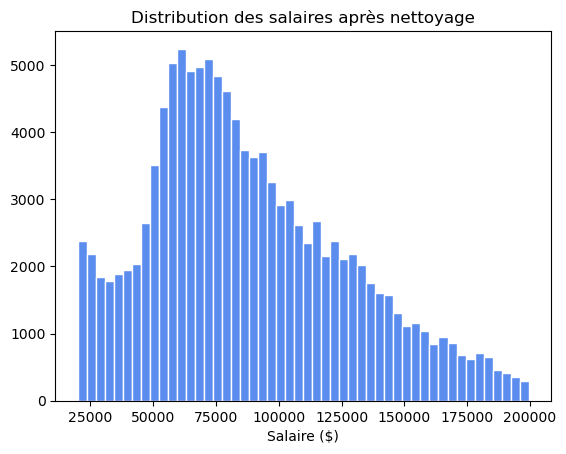

In [6]:
df = df[["JobTitle", "BasePay", "OvertimePay", "TotalPay", "Year"]].copy()

# Target = TotalPay
df = df.dropna(subset=["TotalPay"])
df["TotalPay"] = pd.to_numeric(df["TotalPay"], errors="coerce")
df = df.dropna(subset=["TotalPay"])

# Garder salaires raisonnables
df = df[(df["TotalPay"] >= 20000) & (df["TotalPay"] <= 400000)]

# Supprimer outliers IQR
Q1  = df["TotalPay"].quantile(0.25)
Q3  = df["TotalPay"].quantile(0.75)
IQR = Q3 - Q1
df  = df[
    (df["TotalPay"] >= Q1 - 1.5 * IQR) &
    (df["TotalPay"] <= Q3 + 1.5 * IQR)
]

# Remplir NaN
df["JobTitle"]    = df["JobTitle"].fillna("Unknown")
df["BasePay"]     = pd.to_numeric(df["BasePay"],    errors="coerce").fillna(0)
df["OvertimePay"] = pd.to_numeric(df["OvertimePay"],errors="coerce").fillna(0)
df["Year"]        = df["Year"].fillna(df["Year"].median())

print(f"Shape après nettoyage : {df.shape}")
print(f"Salaire moyen  : ${df['TotalPay'].mean():,.0f}")
print(f"Salaire min    : ${df['TotalPay'].min():,.0f}")
print(f"Salaire max    : ${df['TotalPay'].max():,.0f}")

plt.hist(df["TotalPay"], bins=50, color="#5B8DEF", edgecolor="white")
plt.title("Distribution des salaires après nettoyage")
plt.xlabel("Salaire ($)")
plt.show()

In [7]:

# TF-IDF sur JobTitle
tfidf_job = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X_job     = tfidf_job.fit_transform(df["JobTitle"])

# Features numériques
X_num = csr_matrix(df[["BasePay", "OvertimePay", "Year"]].values)

# Combiner
X_transformed = hstack([X_job, X_num])
y = df["TotalPay"]

print(f"Shape finale : {X_transformed.shape}")
print("Features OK ✓")

Shape finale : (118556, 503)
Features OK ✓


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42
)

if sp.issparse(X_train):
    X_train_dense = X_train.toarray()
    X_test_dense  = X_test.toarray()
else:
    X_train_dense = X_train
    X_test_dense  = X_test

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dense)
X_test_scaled  = scaler.transform(X_test_dense)

print(f"Train : {X_train_scaled.shape}  |  Test : {X_test_scaled.shape}")
print("OK ✓")

Train : (94844, 503)  |  Test : (23712, 503)
OK ✓


In [9]:
baseline = {
    "Ridge":             Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print("Cross Validation 5 folds...\n")
for name, model in baseline.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring="r2", n_jobs=-1
    )
    print(f"{name:<25} R²={scores.mean():.4f}  std={scores.std():.4f}")

Cross Validation 5 folds...

Ridge                     R²=0.9762  std=0.0015
Random Forest             R²=0.9788  std=0.0007
Gradient Boosting         R²=0.9786  std=0.0013


In [10]:
grid_ridge = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5, scoring="r2", n_jobs=-1
)
grid_ridge.fit(X_train_scaled, y_train)
print(f"Meilleur alpha : {grid_ridge.best_params_}")
print(f"Meilleur R²    : {grid_ridge.best_score_:.4f}")

Meilleur alpha : {'alpha': 100.0}
Meilleur R²    : 0.9762


In [13]:
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        "n_estimators": [100],
        "max_depth":    [10, 20],
    },
    cv=3, scoring="r2", n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_scaled, y_train)
print(f"Meilleurs params : {grid_rf.best_params_}")
print(f"Meilleur R²      : {grid_rf.best_score_:.4f}")

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Meilleurs params : {'max_depth': 20, 'n_estimators': 100}
Meilleur R²      : 0.9787


In [14]:
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        "n_estimators":  [100],
        "learning_rate": [0.05, 0.1],
        "max_depth":     [3, 5],
    },
    cv=3, scoring="r2", n_jobs=-1, verbose=1
)
grid_gb.fit(X_train_scaled, y_train)
print(f"Meilleurs params : {grid_gb.best_params_}")
print(f"Meilleur R²      : {grid_gb.best_score_:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Meilleurs params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Meilleur R²      : 0.9813


In [15]:
final_models = {
    "Ridge":             grid_ridge.best_estimator_,
    "Random Forest":     grid_rf.best_estimator_,
    "Gradient Boosting": grid_gb.best_estimator_,
}

results = {}
print(f"{'Modèle':<30} {'R²':>8} {'RMSE':>12} {'MAE':>12}")
print("-" * 65)

for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    r2     = r2_score(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    results[name] = {"r2": r2, "rmse": rmse, "mae": mae, "y_pred": y_pred}
    status = "✓" if r2 >= 0.8 else "✗"
    print(f"{name:<30} {r2:>8.4f} {rmse:>12,.0f} {mae:>12,.0f}  {status}")

best_name = max(results, key=lambda k: results[k]["r2"])
print(f"\nMEILLEUR MODELE : {best_name}  R²={results[best_name]['r2']:.4f}")

Modèle                               R²         RMSE          MAE
-----------------------------------------------------------------
Ridge                            0.9754        6,207        2,924  ✓
Random Forest                    0.9774        5,948        2,662  ✓
Gradient Boosting                0.9811        5,433        2,755  ✓

MEILLEUR MODELE : Gradient Boosting  R²=0.9811


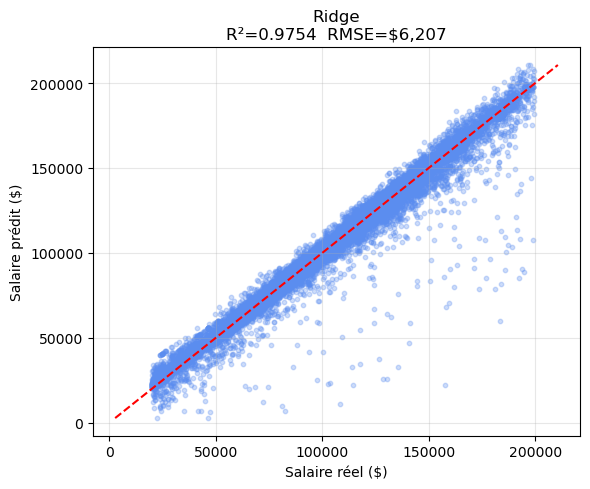

In [17]:
name = "Ridge"
v    = results[name]

plt.figure(figsize=(6, 5))
plt.scatter(y_test, v["y_pred"], alpha=0.3, s=10, color="#5B8DEF")
lim = [min(y_test.min(), v["y_pred"].min()), max(y_test.max(), v["y_pred"].max())]
plt.plot(lim, lim, "r--", linewidth=1.5)
plt.title(f"Ridge\nR²={v['r2']:.4f}  RMSE=${v['rmse']:,.0f}")
plt.xlabel("Salaire réel ($)")
plt.ylabel("Salaire prédit ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

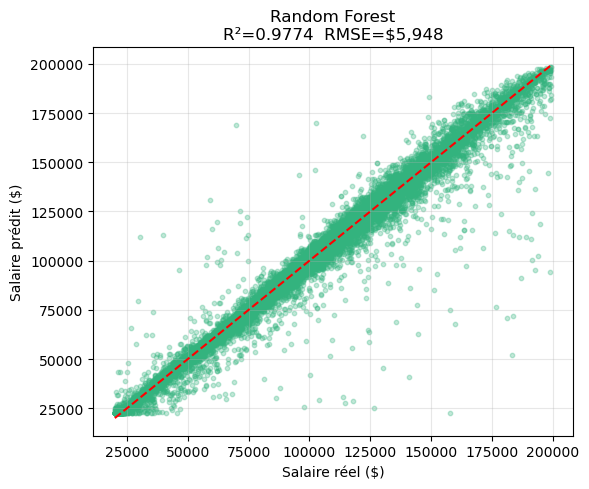

In [18]:
name = "Random Forest"
v    = results[name]

plt.figure(figsize=(6, 5))
plt.scatter(y_test, v["y_pred"], alpha=0.3, s=10, color="#33B37E")
lim = [min(y_test.min(), v["y_pred"].min()), max(y_test.max(), v["y_pred"].max())]
plt.plot(lim, lim, "r--", linewidth=1.5)
plt.title(f"Random Forest\nR²={v['r2']:.4f}  RMSE=${v['rmse']:,.0f}")
plt.xlabel("Salaire réel ($)")
plt.ylabel("Salaire prédit ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

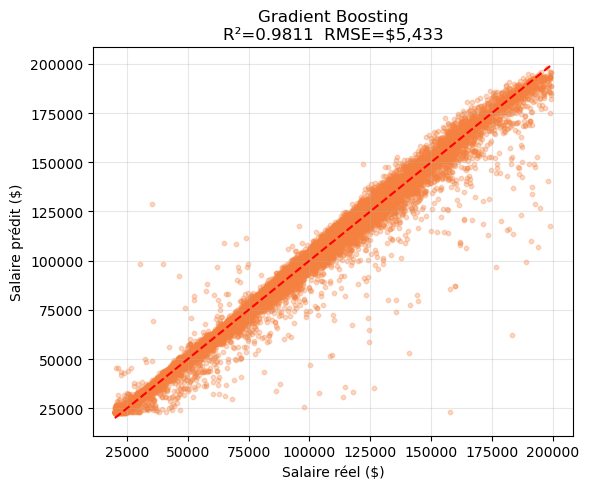

In [19]:
name = "Gradient Boosting"
v    = results[name]

plt.figure(figsize=(6, 5))
plt.scatter(y_test, v["y_pred"], alpha=0.3, s=10, color="#F4813F")
lim = [min(y_test.min(), v["y_pred"].min()), max(y_test.max(), v["y_pred"].max())]
plt.plot(lim, lim, "r--", linewidth=1.5)
plt.title(f"Gradient Boosting\nR²={v['r2']:.4f}  RMSE=${v['rmse']:,.0f}")
plt.xlabel("Salaire réel ($)")
plt.ylabel("Salaire prédit ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

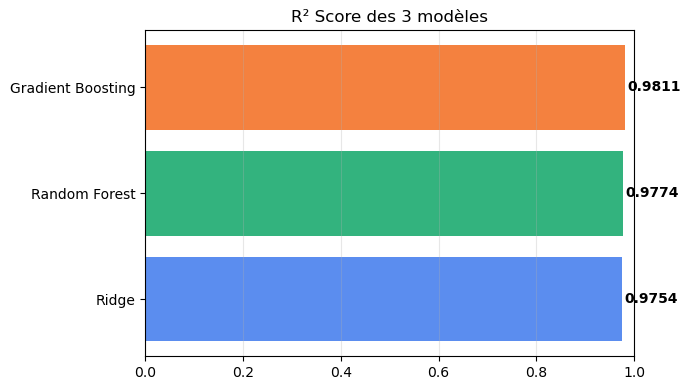

In [30]:
names   = list(results.keys())
r2_vals = [results[n]["r2"] for n in names]
clrs    = ["#5B8DEF", "#33B37E", "#F4813F"]

plt.figure(figsize=(7, 4))
bars = plt.barh(names, r2_vals, color=clrs)
plt.title("R² Score des 3 modèles")
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, axis="x")
for b, v in zip(bars, r2_vals):
    plt.text(v+0.005, b.get_y()+b.get_height()/2,
             f"{v:.4f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

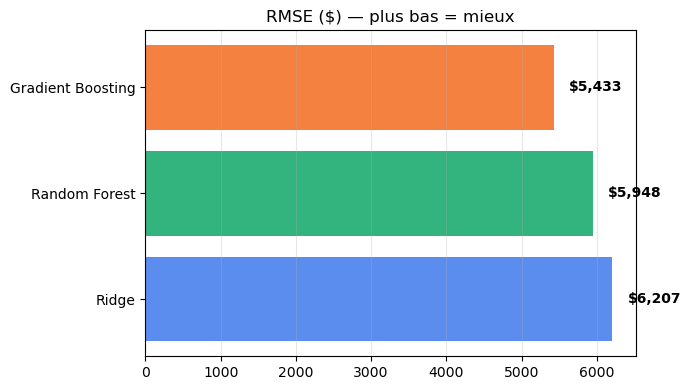

In [27]:
rm_vals = [results[n]["rmse"] for n in names]

plt.figure(figsize=(7, 4))
bars = plt.barh(names, rm_vals, color=clrs)
plt.title("RMSE ($) — plus bas = mieux")
plt.grid(True, alpha=0.3, axis="x")
for b, v in zip(bars, rm_vals):
    plt.text(v+200, b.get_y()+b.get_height()/2,
             f"${v:,.0f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

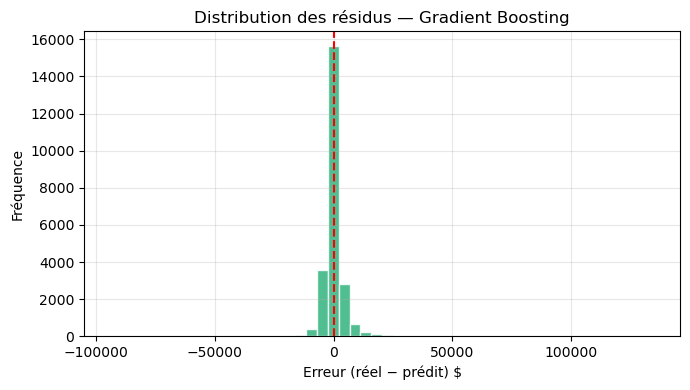

In [28]:
residus = y_test.values - results[best_name]["y_pred"]

plt.figure(figsize=(7, 4))
plt.hist(residus, bins=50, color="#33B37E", edgecolor="white", alpha=0.85)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.title(f"Distribution des résidus — {best_name}")
plt.xlabel("Erreur (réel − prédit) $")
plt.ylabel("Fréquence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

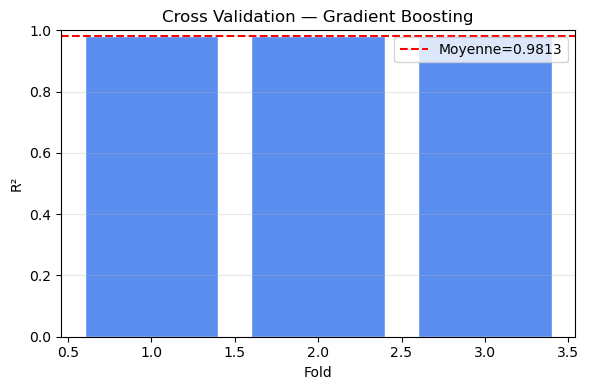

In [31]:
scores = cross_val_score(
    final_models[best_name],
    X_train_scaled, y_train,
    cv=3, scoring="r2"
)

plt.figure(figsize=(6, 4))
plt.bar(range(1, len(scores)+1), scores, color="#5B8DEF", edgecolor="white")
plt.axhline(scores.mean(), color="red", linestyle="--",
            label=f"Moyenne={scores.mean():.4f}")
plt.title(f"Cross Validation — {best_name}")
plt.xlabel("Fold")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()